In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import seaborn as sns

In [2]:
np.random.seed(0)

In [3]:
data_points, centroid = make_blobs(n_samples=5000, centers=[[4,4], [-2, -1], [2, -3], [1, 1]], cluster_std=.9)


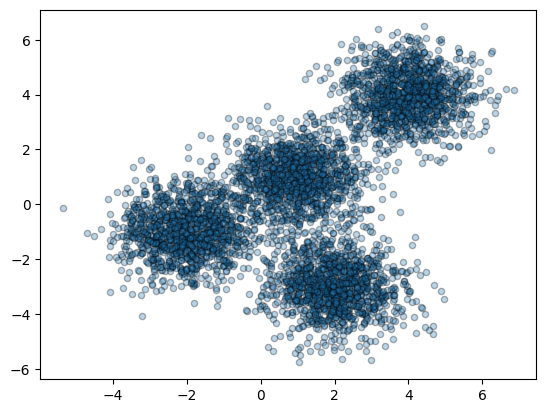

In [4]:
plt.scatter(data_points[:, 0], data_points[:, 1], marker='.',alpha=0.3,ec='k',s=80)

In [5]:
k_mean = KMeans(init = "k-means++", n_clusters = 4, n_init = 12)
k_mean.fit(data_points)
k_labels = k_mean.labels_
k_labels

array([0, 3, 3, ..., 1, 0, 0], shape=(5000,), dtype=int32)

In [6]:
k_cluster_cen = k_mean.cluster_centers_
k_cluster_cen

array([[-2.03743147, -0.99782524],
       [ 3.97334234,  3.98758687],
       [ 0.96900523,  0.98370298],
       [ 1.99741008, -3.01666822]])

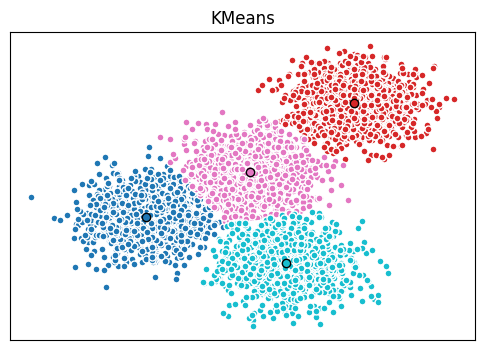

In [8]:
fig = plt.figure(figsize=(6, 4))

colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_labels))))

ax = fig.add_subplot(1, 1, 1)

for k, col in zip(range(len([[4, 4], [-2, -1], [2, -3], [1, 1]])), colors):

    my_members = (k_labels == k)

    cluster_center = k_cluster_cen[k]

    ax.plot(data_points[my_members, 0], data_points[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=10)
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

ax.set_title('KMeans')
ax.set_xticks(())
ax.set_yticks(())
plt.show()

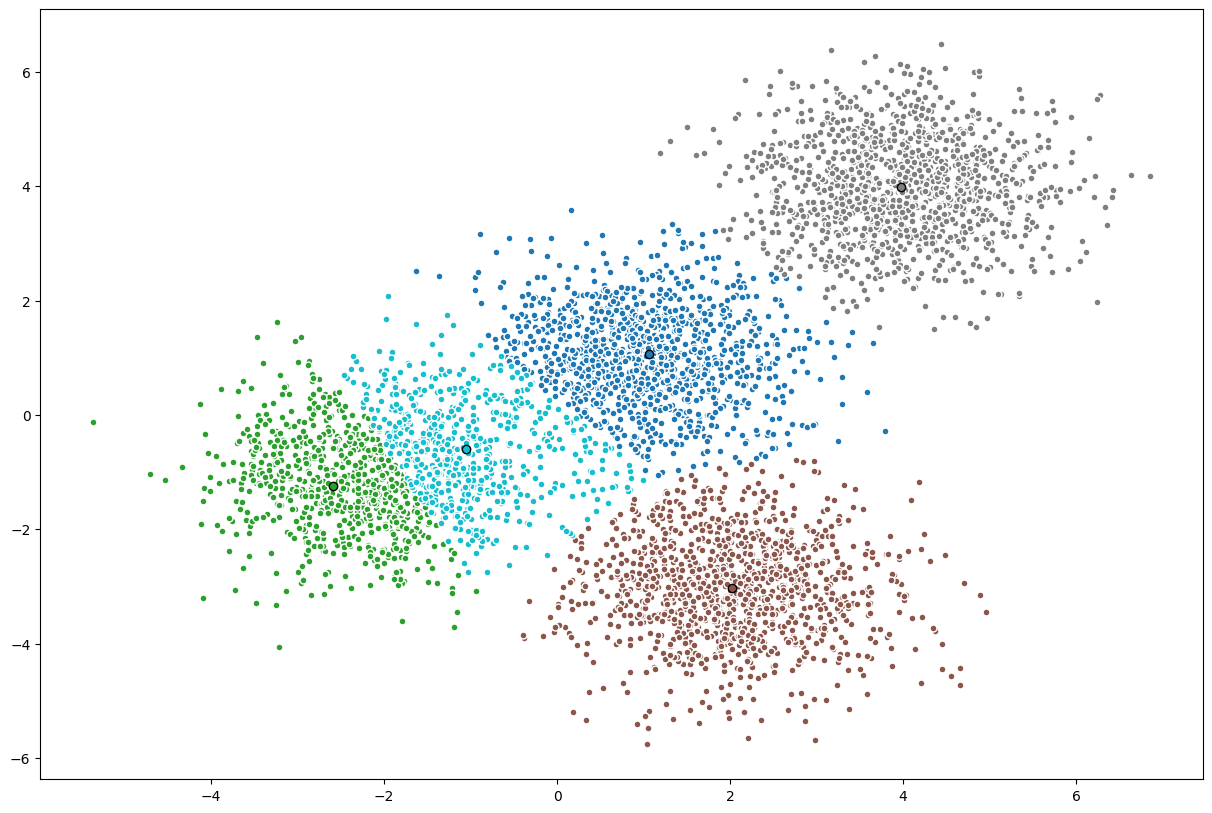

In [53]:
K5 = KMeans(init='k-means++', n_clusters=5, n_init=15)
K5.fit(data_points)
L5=K5.labels_
C5=K5.cluster_centers_
fig = plt.figure(figsize=(15,10))
paint = plt.cm.tab10(np.linspace(0, 1, len(set(L5))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(C5)), paint):
    my_members = (L5 == k)
    cluster_center = C5[k]
    ax.plot(data_points[my_members, 0], data_points[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=10)
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', ms=6)
plt.show()

In [28]:
loc = "C:/Users/LAPTOP/Downloads/Cust_Segmentation.csv"
segm_data = pd.read_csv(loc)
segm_data

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2
...,...,...,...,...,...,...,...,...,...,...
845,846,27,1,5,26,0.548,1.220,NaN,NBA007,6.8
846,847,28,2,7,34,0.359,2.021,0.0,NBA002,7.0
847,848,25,4,0,18,2.802,3.210,1.0,NBA001,33.4
848,849,32,1,12,28,0.116,0.696,0.0,NBA012,2.9


In [41]:
#segm_data = segm_data.drop('Address',axis=1)
segm_data = segm_data.dropna()
segm_data.info()
data_p = segm_data.values[:,1:]

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      700 non-null    int64  
 1   Age              700 non-null    int64  
 2   Edu              700 non-null    int64  
 3   Years Employed   700 non-null    int64  
 4   Income           700 non-null    int64  
 5   Card Debt        700 non-null    float64
 6   Other Debt       700 non-null    float64
 7   Defaulted        700 non-null    float64
 8   DebtIncomeRatio  700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 54.7 KB


In [44]:
dataset_c = StandardScaler().fit_transform(data_p)
dataset_c

array([[ 0.76830405,  0.29879269, -0.35900652, ..., -0.60428433,
        -0.59494973, -0.58052847],
       [ 1.51908977, -0.77932527,  2.64702891, ...,  1.5706204 ,
        -0.59494973,  0.37222169],
       [-0.23274357,  0.29879269,  0.24220057, ...,  0.83520125,
         1.68081427,  1.55949495],
       ...,
       [-1.2337912 ,  2.45502862, -1.26081715, ...,  0.04620852,
         1.68081427,  3.39170678],
       [-0.35787453, -0.77932527,  0.54280411, ..., -0.71904138,
        -0.59494973, -1.07889008],
       [ 2.14474454, -0.77932527,  1.1440112 , ...,  0.17648972,
        -0.59494973, -0.24340149]], shape=(700, 8))

In [45]:
clust_no=4
segm_mean = KMeans(init="k-means++",n_clusters=clust_no,n_init=20)
segm_mean.fit(data_p)
label=segm_mean.labels_
segm_data['Cluster Group'] = label

In [46]:
segm_data

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,Cluster Group
0,1,41,2,6,19,0.124,1.073,0.0,6.3,0
1,2,47,1,26,100,4.582,8.218,0.0,12.8,2
2,3,33,2,10,57,6.111,5.802,1.0,20.9,1
3,4,29,2,4,19,0.681,0.516,0.0,6.3,0
4,5,47,1,31,253,9.308,8.908,0.0,7.2,3
...,...,...,...,...,...,...,...,...,...,...
844,845,41,1,7,43,0.694,1.198,0.0,4.4,0
846,847,28,2,7,34,0.359,2.021,0.0,7.0,0
847,848,25,4,0,18,2.802,3.210,1.0,33.4,0
848,849,32,1,12,28,0.116,0.696,0.0,2.9,0


In [48]:
segm_data.groupby("Cluster Group").mean()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Cluster Group,,,,,,,,,
0,438.652079,31.796499,1.632385,5.205689,27.614880,0.882066,1.862825,0.295405,10.071335
1,427.625668,39.604278,1.796791,12.839572,61.454545,2.349251,4.451139,0.208556,11.051872
2,372.632653,43.714286,2.163265,19.448980,121.306122,3.724265,7.237184,0.122449,9.136735
3,376.285714,46.142857,2.571429,19.857143,266.428571,8.941857,14.634429,0.428571,9.342857


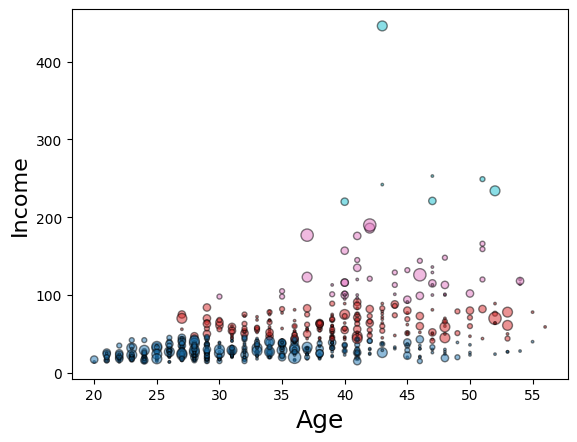

In [55]:
area = np.pi * ( data_p[:, 1])**2  
plt.scatter(data_p[:, 0], data_p[:, 3], s=area, c=label.astype(float), cmap='tab10', ec='k',alpha=0.5)
plt.xlabel('Age', fontsize=18)
plt.ylabel('Income', fontsize=16)
plt.show()

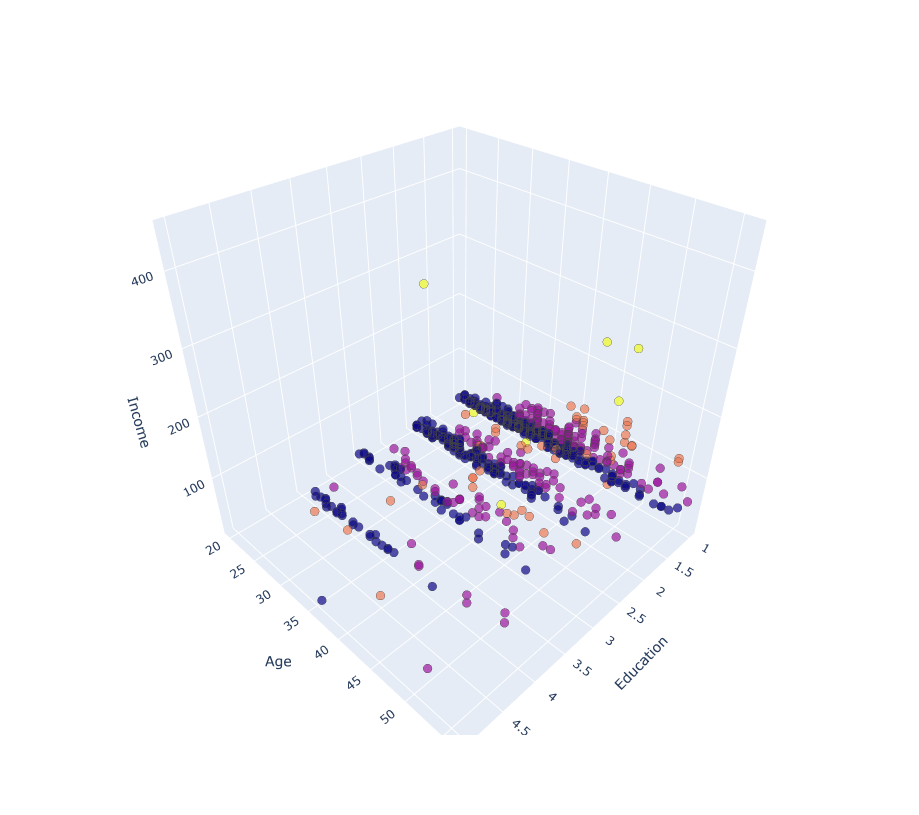

In [54]:
# Create interactive 3D scatter plot
fig = px.scatter_3d(data_p, x=1, y=0, z=3, opacity=0.7, color=label.astype(float))

fig.update_traces(marker=dict(size=5, line=dict(width=.25)), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800, scene=dict(
        xaxis=dict(title='Education'),
        yaxis=dict(title='Age'),
        zaxis=dict(title='Income')
    ))  # Remove color bar, resize plot

fig.show()

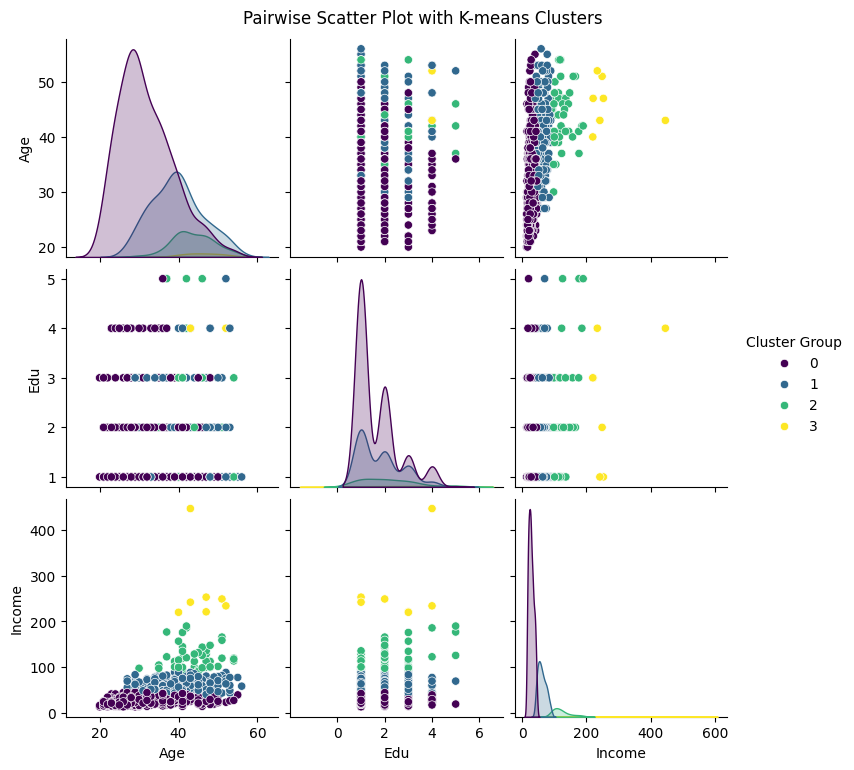

In [56]:
segm_sub = segm_data[['Age', 'Edu','Income','Cluster Group']].copy() 
sns.pairplot(segm_sub, hue='Cluster Group', palette='viridis', diag_kind='kde') 
plt.suptitle('Pairwise Scatter Plot with K-means Clusters', y=1.02)
plt.show()